## Student Name: Puspa Raj Chadudhary
## Student ID: 2408828
## Worksheet4


## Setup: Mount Google Drive & Extract Dataset

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import zipfile

# Path to your zip file
zip_path = "/content/Copy of devnagari digit.zip"

# Destination folder
extract_path = "/content/extracted_files"

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


KeyboardInterrupt: 

In [24]:
import os

# Verify the directory structure
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # Only show files 2 levels deep
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:  # Show only first 3 files per folder
            print(f'{subindent}{f}')

extracted_files/
  .ipynb_checkpoints/
  DevanagariHandwrittenDigitDataset/
    Test/
      digit_0/
      digit_3/
      digit_9/
      digit_1/
      digit_2/
      digit_6/
      digit_7/
      digit_4/
      digit_8/
      digit_5/
    Train/
      digit_0/
      digit_3/
      digit_1/
      digit_2/
      digit_6/
      digit_7/
      digit_4/
      digit_8/
      digit_5/


## Import Libraries

In [25]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")

TensorFlow version: 2.19.0
Keras version: 3.13.2


---
## Task 1: Data Preparation
Load images from the dataset directory, convert to numpy arrays, normalize, and one-hot encode labels.

In [27]:
# ── Configuration ──────────────────────────────────────────────────────────────
# Update these paths if your dataset is extracted to a different location
BASE_DIR   = '/content/DevanagariHandwrittenDigitDataset'
TRAIN_DIR  = os.path.join(BASE_DIR, 'Train')
TEST_DIR   = os.path.join(BASE_DIR, 'Test')

IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

# ── Helper function ────────────────────────────────────────────────────────────
def load_images_from_folder(folder):
    """
    Loads images and labels from a folder structured as:
        folder/
            digit_0/  image1.png  image2.png ...
            digit_1/  ...
            ...

    Returns:
        images : np.ndarray of shape (N, 28, 28, 1), dtype float32, range [0,1]
        labels : np.ndarray of shape (N,), dtype int
    """
    images, labels = [], []
    class_names = sorted(os.listdir(folder))          # e.g. ['digit_0', 'digit_1', ...]
    class_map   = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')              # grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))            # 28×28
                img = np.array(img, dtype=np.float32) / 255.0       # normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

# ── Load data ──────────────────────────────────────────────────────────────────
print("Loading training data...")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

print("Loading test data...")
x_test_raw,  y_test_raw  = load_images_from_folder(TEST_DIR)

print(f"\nRaw training set : {x_train_raw.shape}  |  Labels: {y_train_raw.shape}")
print(f"Raw test set     : {x_test_raw.shape}   |  Labels: {y_test_raw.shape}")

Loading training data...
Loading test data...

Raw training set : (17000, 28, 28)  |  Labels: (17000,)
Raw test set     : (3000, 28, 28)   |  Labels: (3000,)


In [30]:
# ── Reshape for Keras (add channel dimension) ───────────────────────────────────
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)  # (N, 28, 28, 1)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)

# ── One-hot encode labels ───────────────────────────────────────────────────────
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

#Shuffle
indices = np.arange(len(x_train))
np.random.seed(42)
np.random.shuffle(indices)
x_train = x_train[indices]
y_train = y_train[indices]

print(f"Training set shape : {x_train.shape}  |  Labels shape: {y_train.shape}")
print(f"Test set shape     : {x_test.shape}   |  Labels shape: {y_test.shape}")
print(f"Pixel value range  : [{x_train.min():.2f}, {x_train.max():.2f}]")
print(f"Class labels       : {np.unique(y_train_raw)}")

Training set shape : (17000, 28, 28, 1)  |  Labels shape: (17000, 10)
Test set shape     : (3000, 28, 28, 1)   |  Labels shape: (3000, 10)
Pixel value range  : [0.00, 1.00]
Class labels       : [0 1 2 3 4 5 6 7 8 9]


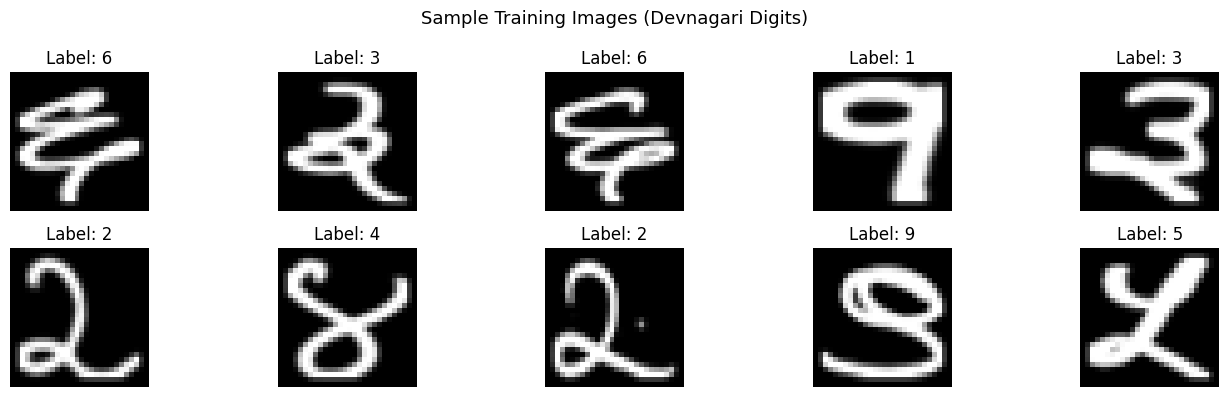

In [31]:
# ── Visualise sample images ─────────────────────────────────────────────────────
plt.figure(figsize=(14, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')
plt.suptitle('Sample Training Images (Devnagari Digits)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 2: Build the FCN Model

Architecture:
- **Input**: 28×28×1 image → flattened to 784
- **Hidden layer 1**: 64 neurons, sigmoid
- **Hidden layer 2**: 128 neurons, sigmoid
- **Hidden layer 3**: 256 neurons, sigmoid
- **Output layer**: 10 neurons, softmax

In [32]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 1)  # (28, 28, 1)

model = keras.Sequential(
    [
        keras.layers.Input(shape=input_shape),
        keras.layers.Flatten(),                               # 28×28×1 → 784
        keras.layers.Dense(64,  activation='sigmoid'),        # Hidden layer 1
        keras.layers.Dense(128, activation='sigmoid'),        # Hidden layer 2
        keras.layers.Dense(256, activation='sigmoid'),        # Hidden layer 3
        keras.layers.Dense(NUM_CLASSES, activation='softmax') # Output layer
    ],
    name='devnagari_fcn'
)

model.summary()

Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3: Compile the Model

In [33]:
model.compile(
    optimizer='adam',                    # Adam optimizer
    loss='categorical_crossentropy',     # One-hot encoded labels → categorical crossentropy
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"  Optimizer : adam")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimizer : adam
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4: Train the Model

In [34]:
BATCH_SIZE = 128
EPOCHS     = 20

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,   # 20% of training data used for validation
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2107 - loss: 2.2094
Epoch 1: val_accuracy improved from None to 0.68588, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3757 - loss: 1.9076 - val_accuracy: 0.6859 - val_loss: 1.2150
Epoch 2/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7457 - loss: 0.9576
Epoch 2: val_accuracy improved from 0.68588 to 0.83559, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7885 - loss: 0.7397 - val_accuracy: 0.8356 - val_loss: 0.4486
Epoch 3/20
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8542 - loss: 0.3976
Epoch 3: val_accuracy improved from 0.83559 to 0.87912, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8591 - loss: 0.3681 - val_accurac

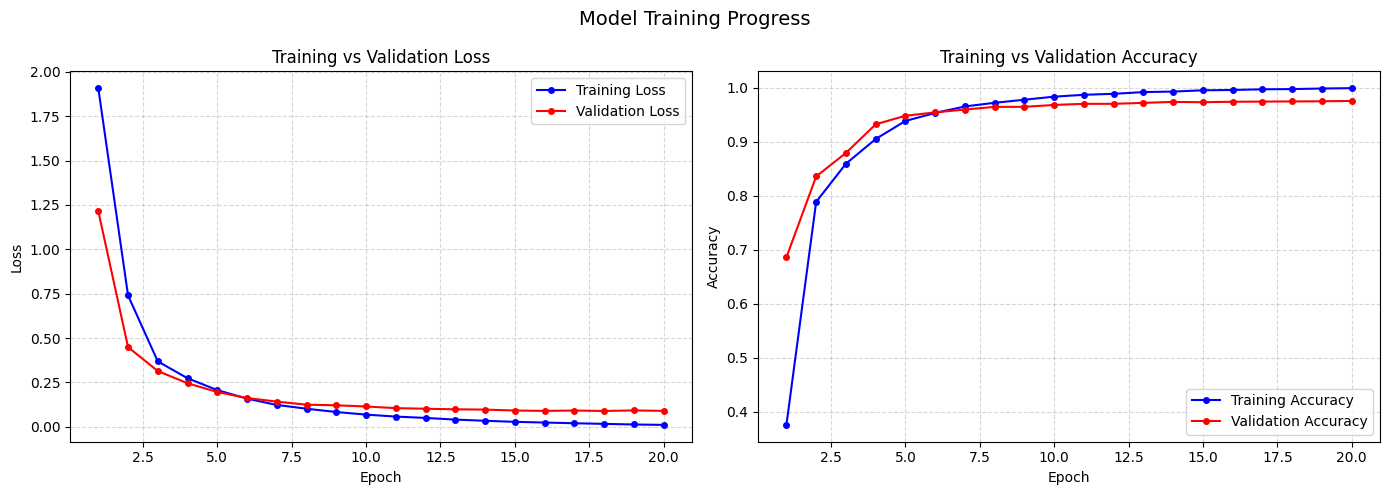

Plot saved as training_history.png


In [35]:
# ── Visualise training history ──────────────────────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_ran, train_loss, 'b-o', markersize=4, label='Training Loss')
ax1.plot(epochs_ran, val_loss,   'r-o', markersize=4, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Accuracy
ax2.plot(epochs_ran, train_acc, 'b-o', markersize=4, label='Training Accuracy')
ax2.plot(epochs_ran, val_acc,   'r-o', markersize=4, label='Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Model Training Progress', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as training_history.png")

---
## Task 5: Evaluate the Model

In [36]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\n{'='*40}")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"{'='*40}")

94/94 - 0s - 3ms/step - accuracy: 0.9777 - loss: 0.0743

  Test Loss     : 0.0743
  Test Accuracy : 0.9777  (97.77%)


---
## Task 6: Save and Load the Model

In [37]:
# ── Save the model ─────────────────────────────────────────────────────────────
save_path = 'devnagari_fcn_model.h5'
model.save(save_path)
print(f"Model saved to: {save_path}")

Model saved to: devnagari_fcn_model.h5


In [38]:
# ── Load the model ─────────────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model(save_path)
print("Model loaded successfully!")

# Re-evaluate to confirm identical performance
reloaded_loss, reloaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"\nRe-evaluated on test set:")
print(f"  Loss     : {reloaded_loss:.4f}")
print(f"  Accuracy : {reloaded_acc:.4f}  ({reloaded_acc*100:.2f}%)")

Model loaded successfully!
94/94 - 1s - 7ms/step - accuracy: 0.9777 - loss: 0.0743

Re-evaluated on test set:
  Loss     : 0.0743
  Accuracy : 0.9777  (97.77%)


---
## Task 7: Make Predictions

In [40]:
# ── Generate predictions ───────────────────────────────────────────────────────
predictions      = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)   # Convert probabilities → class indices
true_labels      = np.argmax(y_test, axis=1)

# Show first 5 predictions
print("Sample Predictions (first 5 test images):\n")
for i in range(5):
    confidence = predictions[i][predicted_labels[i]] * 100
    status     = '✓' if predicted_labels[i] == true_labels[i] else '✗'
    print(f"  [{status}] Image {i+1} | Predicted: {predicted_labels[i]}  "
          f"| True: {true_labels[i]}  | Confidence: {confidence:.1f}%")

Sample Predictions (first 5 test images):

  [✓] Image 1 | Predicted: 0  | True: 0  | Confidence: 99.9%
  [✓] Image 2 | Predicted: 0  | True: 0  | Confidence: 99.6%
  [✓] Image 3 | Predicted: 0  | True: 0  | Confidence: 99.5%
  [✓] Image 4 | Predicted: 0  | True: 0  | Confidence: 100.0%
  [✓] Image 5 | Predicted: 0  | True: 0  | Confidence: 100.0%


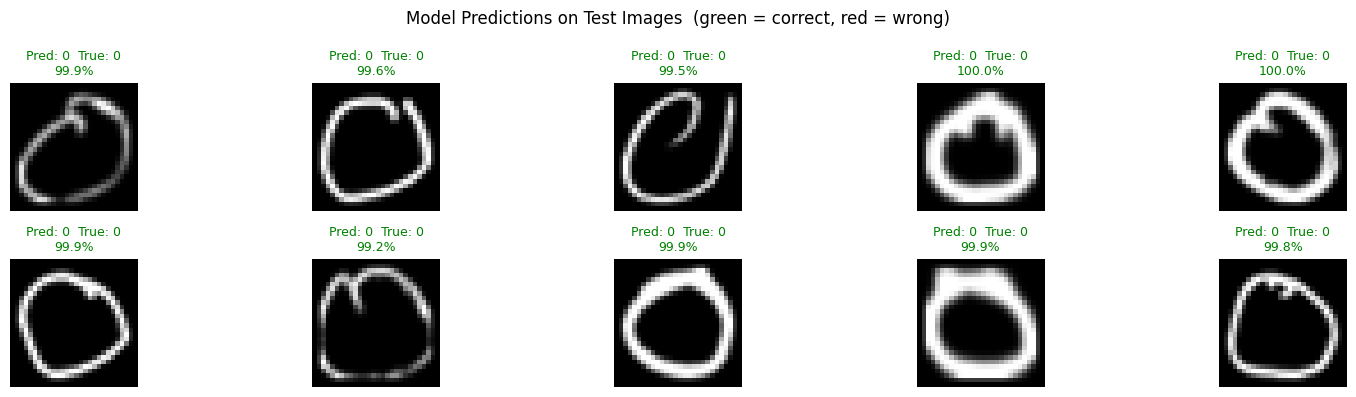

Predictions plot saved as predictions.png


In [41]:
# ── Visualise predictions ──────────────────────────────────────────────────────
num_show = 10
plt.figure(figsize=(16, 4))

for i in range(num_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')

    pred  = predicted_labels[i]
    true  = true_labels[i]
    conf  = predictions[i][pred] * 100
    color = 'green' if pred == true else 'red'

    plt.title(f"Pred: {pred}  True: {true}\n{conf:.1f}%", color=color, fontsize=9)
    plt.axis('off')

plt.suptitle('Model Predictions on Test Images  (green = correct, red = wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Predictions plot saved as predictions.png")

In [42]:
# ── Final summary ──────────────────────────────────────────────────────────────
correct   = np.sum(predicted_labels == true_labels)
incorrect = len(true_labels) - correct

print("\n" + "="*45)
print("         FINAL RESULTS SUMMARY")
print("="*45)
print(f"  Total test samples  : {len(true_labels)}")
print(f"  Correct predictions : {correct}")
print(f"  Wrong predictions   : {incorrect}")
print(f"  Test Accuracy       : {test_acc*100:.2f}%")
print("="*45)


         FINAL RESULTS SUMMARY
  Total test samples  : 3000
  Correct predictions : 2933
  Wrong predictions   : 67
  Test Accuracy       : 97.77%
